# 泰坦尼克号案例

### 数据信息展示

In [16]:
import pandas as pd

# 读取data文件夹下的titanic.csv文件
# 文件路径错误或者文件不存在，检查路径或确保文件已放置在 data 文件夹下
titanic_df = pd.read_csv('data/titanic.csv')  # 确保 'data/titanic.csv' 文件存在，或修改为实际路径

# 查看前几行数据以确认读取成功
titanic_df.head()

titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   row.names  1313 non-null   int64  
 1   pclass     1313 non-null   str    
 2   survived   1313 non-null   int64  
 3   name       1313 non-null   str    
 4   age        633 non-null    float64
 5   embarked   821 non-null    str    
 6   home.dest  754 non-null    str    
 7   room       77 non-null     str    
 8   ticket     69 non-null     str    
 9   boat       347 non-null    str    
 10  sex        1313 non-null   str    
dtypes: float64(1), int64(2), str(8)
memory usage: 113.0 KB


### 设置特征与标签

In [17]:
# 取 pclass age sex 作为特征，survived 作为标签
# 首先，选择需要的特征列和标签列
features = titanic_df[['pclass', 'age', 'sex']]
labels = titanic_df['survived']

### 分析数据中 sex 与 survived 的关联关系

不同性别的生存情况：
survived    0    1
sex               
female    156  307
male      708  142

不同性别的生存率：
sex
female    0.663067
male      0.167059
Name: survived, dtype: float64


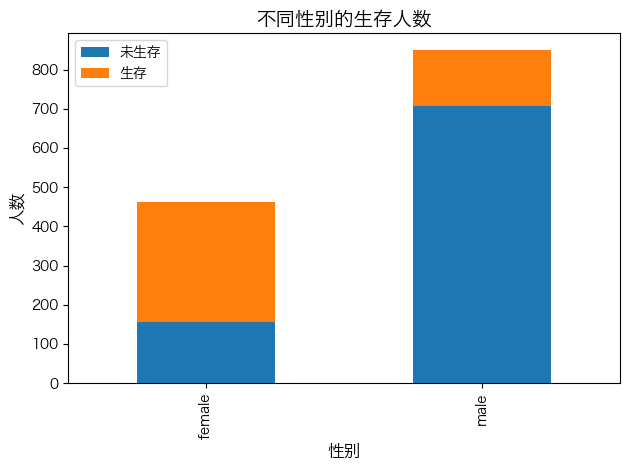

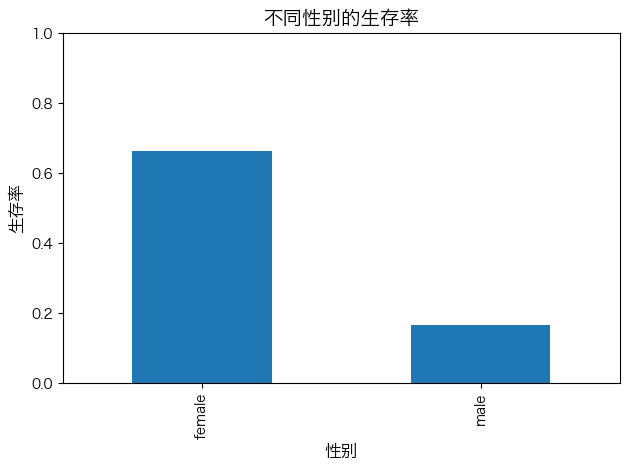

In [18]:
# 分析 sex 特征与 survived 标签的关联关系

# 1. 以 sex 分组，查看每组生存与未生存的数量
sex_survived_count = titanic_df.groupby(['sex', 'survived']).size().unstack()
print("不同性别的生存情况：")
print(sex_survived_count)

# 2. 计算各性别的生存率
sex_survival_rate = titanic_df.groupby('sex')['survived'].mean()
print("\n不同性别的生存率：")
print(sex_survival_rate)

# 3. 可视化展示性别与生存情况的关系
import matplotlib.pyplot as plt

# 设置中文字体为 Mac 常用字体
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Hiragino Sans GB', 'Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

ax = sex_survived_count.plot(kind='bar', stacked=True)
plt.title('不同性别的生存人数', fontsize=14)
plt.xlabel('性别', fontsize=12)
plt.ylabel('人数', fontsize=12)
plt.legend(['未生存', '生存'], fontsize=10)
plt.tight_layout()
plt.show()

ax2 = sex_survival_rate.plot(kind='bar')
plt.title('不同性别的生存率', fontsize=14)
plt.xlabel('性别', fontsize=12)
plt.ylabel('生存率', fontsize=12)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### 训练决策树分类模型

#### 决策树优先可调超参数（`DecisionTreeClassifier`）

| 优先级 | 超参数 | 含义 | 调参方向 |
|--------|--------|------|----------|
| ⭐⭐⭐ | `max_depth` | 树的最大深度，控制模型复杂度 | 太小欠拟合，太大过拟合；常用 3~10 |
| ⭐⭐⭐ | `min_samples_split` | 内部节点再分裂所需的最小样本数 | 增大 → 树更简单、更不易过拟合 |
| ⭐⭐⭐ | `min_samples_leaf` | 叶节点最少样本数 | 增大 → 叶节点更“稳”，泛化更好 |
| ⭐⭐ | `max_features` | 每次分裂考虑的特征数 | 减小 → 增加随机性，类似随机森林思路 |
| ⭐⭐ | `criterion` | 分裂质量度量：`gini`（默认）或 `entropy` | 二者通常差异不大，可对比选优 |
| ⭐ | `min_impurity_decrease` | 分裂必须带来的最小不纯度下降 | 增大 → 抑制无效分裂 |
| ⭐ | `class_weight` | 类别权重，处理样本不平衡 | 如 `{0:1, 1:2}` 提高少数类召回 |
| — | `random_state` | 随机种子，保证结果可复现 | 固定即可，非“调参”项 |

**当前默认模型**只用了 `random_state=42`，其余均为 sklearn 默认值（树会尽量长到拟合训练集，容易过拟合）。  
**建议下一步**：用 `GridSearchCV` 或 `RandomizedSearchCV` 对 `max_depth`、`min_samples_split`、`min_samples_leaf` 做交叉验证搜索。


In [19]:
# ******** 数据预处理 ********
# 将 pclass 特征转换为数值类型
features['pclass'] = features['pclass'].map({'1st': 1, '2nd': 2, '3rd': 3})

# 对 sex 特征进行数值编码
features['sex'] = features['sex'].map({'male': 0, 'female': 1})

# 缺失值处理：用年龄中位数填充
features['age'] = features['age'].fillna(features['age'].median())

# ******** 模型划分 ********
# 划分训练集和测试集
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)

# ******** 模型训练 ********
# 使用决策树进行分类
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score


# 可调超参见上方表格；优先调 max_depth / min_samples_split / min_samples_leaf
# 剪枝主要使用的是 max_depth（最大树深）、min_samples_leaf（最小叶子节点样本数）、ccp_alpha（基于成本复杂度剪枝）等参数
# min_samples_split 虽有简单防止过拟合的作用，但不是最直接的“剪枝”手段
# 下面代码举例采用 max_depth=5、min_samples_leaf=3、ccp_alpha=0.01 演示常见剪枝效果
clf = DecisionTreeClassifier(
    random_state=42, 
    max_depth=5,               # 控制最大树深，常用剪枝参数
    min_samples_leaf=3,        # 每个叶子最少样本数（可防止单样本叶子，提升泛化）
    ccp_alpha=0.01             # 成本复杂度剪枝参数，>0 会主动剪去测试分数提升小的分支
)
clf.fit(X_train, y_train)

# ******** 预测与评估 ********
y_pred = clf.predict(X_test)

print("决策树分类准确率：", accuracy_score(y_test, y_pred))
print("\n分类报告：\n", classification_report(y_test, y_pred))

# 上述代码主要完成了泰坦尼克号数据的特征预处理和基于决策树的分类任务。具体包括：
# 1. 对特征 pclass 和 sex 进行了数值编码，方便后续模型处理。
# 2. 对年龄（age）中的缺失值用中位数进行了填充，保证数据完整性。
# 3. 使用 train_test_split 将数据集划分为训练集和测试集。
# 4. 训练了一个决策树分类模型（DecisionTreeClassifier），并用测试集进行了预测。
# 5. 输出了决策树模型在测试集上的分类准确率以及详细的分类报告（precision、recall、f1-score等）。

决策树分类准确率： 0.8324873096446701

分类报告：
               precision    recall  f1-score   support

           0       0.80      0.98      0.88       245
           1       0.94      0.60      0.73       149

    accuracy                           0.83       394
   macro avg       0.87      0.79      0.80       394
weighted avg       0.85      0.83      0.82       394



In [20]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(80,50), dpi=300)
tree.plot_tree(
    clf,                                  # 决策树模型
    feature_names=features.columns,        # 特征的名字（用于在图中显示）
    class_names=['未生存', '生存'],        # 类别的名字（显示在节点中）
    filled=True,                          # 是否用颜色填充节点
    rounded=True,                         # 是否使用圆角框显示节点
    fontsize=10                           # 字体大小
)
plt.title("泰坦尼克号决策树")
plt.show()

# 随机森林

随机森林分类准确率： 0.8375634517766497

随机森林分类报告：
               precision    recall  f1-score   support

           0       0.81      0.97      0.88       245
           1       0.93      0.62      0.74       149

    accuracy                           0.84       394
   macro avg       0.87      0.79      0.81       394
weighted avg       0.85      0.84      0.83       394



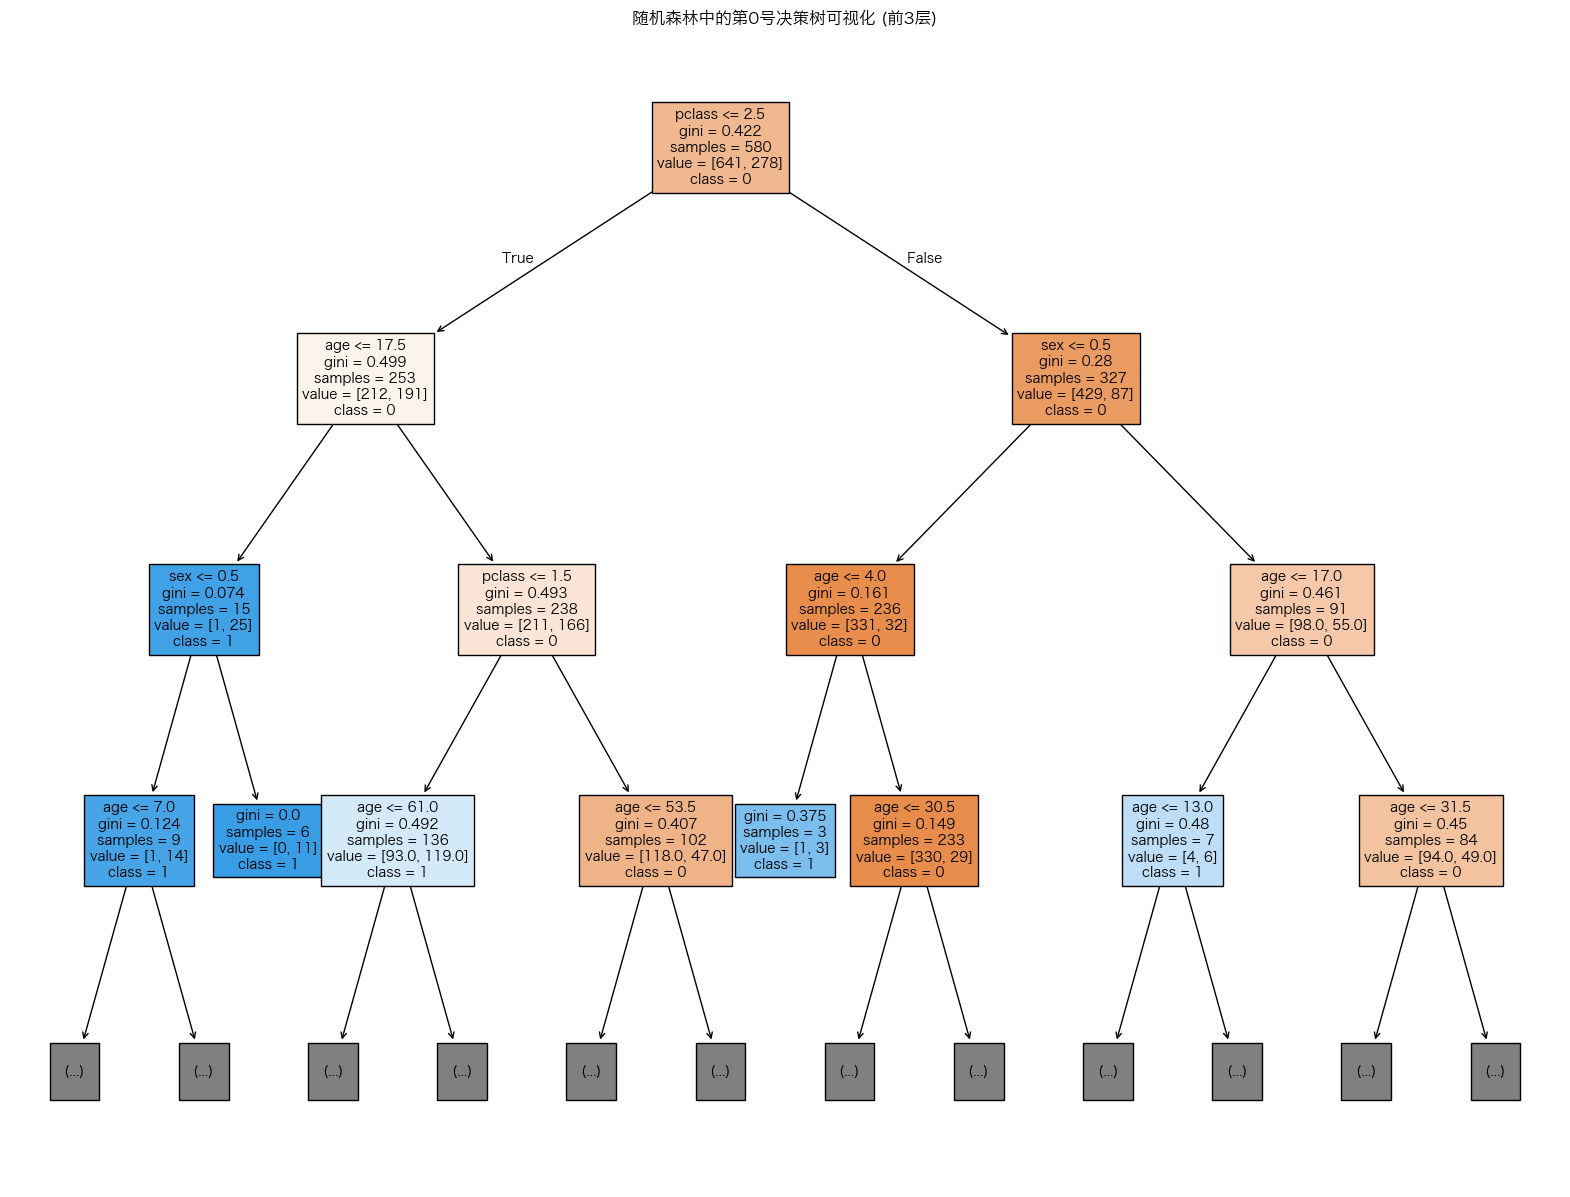

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 随机森林是一种集成学习方法，能有效缓解单棵决策树易过拟合、对样本扰动敏感等问题
# 训练问题说明：
# 1. 单棵决策树容易对训练数据过拟合，泛化能力较差。
# 2. 对数据中的噪声较为敏感，鲁棒性不足。
# 解决方式：
# 随机森林通过集成多棵决策树，并在训练过程中对样本和特征进行随机抽样，实现“投票”决策，有效提升了模型的稳定性和泛化能力。

# 构建随机森林分类器
rf_clf = RandomForestClassifier(
    n_estimators=100,       # 森林中树的数量
    max_depth=5,            # 控制单棵决策树最大深度（与上文保持一致便于对比）
    min_samples_leaf=3,     # 每个叶子节点最小样本数
    random_state=42
)
# RandomForestClassifier 常用入参及其含义说明：
# - n_estimators: 森林中树的数量。树越多通常效果更好但计算量增大，默认为100。
# - criterion: 用于分裂节点的指标，"gini"（基尼系数）或"entropy"（信息增益），默认为"gini"。
# - max_depth: 单棵树的最大深度。防止过拟合，默认None表示直到每个叶节点只剩最少样本。
# - min_samples_split: 内部节点再划分所需的最小样本数，默认为2。增大可以防止过拟合。
# - min_samples_leaf: 叶节点所需的最小样本数。防止树生成过深。
# - max_features: 控制每棵树在每次寻找最佳分裂点时考虑的最大特征数，用于增加多样性从而防止过拟合。可以取：
#     - "auto"（或 None）：对于分类问题，相当于sqrt(n_features)；对于回归，相当于n_features。
#     - "sqrt"：每次分裂时随机挑选sqrt(特征总数)个特征进行最优划分搜索，默认分类问题为此值。
#     - "log2"：每次分裂时随机挑选log2(特征总数)个特征参与分裂。
#     - 整数：每次分裂直接指定考虑的特征个数。
#     - 浮点数（0~1之间）：每次分裂使用按比例抽取的特征数（如0.5表示使用一半特征）。
#   适当减小max_features可以提升模型泛化能力，增加随机性。
# - bootstrap: 是否在建树时采用bootstrap采样（有放回抽样），默认为True。
# - max_samples: 如果采用bootstrap采样，则每棵树从原始样本中有放回抽样的最大样本数。可设为整数或0-1之间小数（表示比例），仅当bootstrap=True时有效，默认None即全部样本。
# - oob_score: 是否采用袋外样本来估计泛化精度，仅当bootstrap=True时有效。
# - n_jobs: 并行运行时用的CPU核心数，-1表示全部用完，快很多。
# - random_state: 随机数种子，保证每次实验结果可复现。
# - class_weight: 样本类别权重，用于类别不平衡处理，如"balanced"。
# - verbose: 控制训练时打印日志的详细程度，0为不输出，越大输出越详细。
# - warm_start: 若为True，则复用上一次调用的结果，新增更多树，适合增量训练。


# 用训练数据训练随机森林模型
rf_clf.fit(X_train, y_train)

# 用测试集进行预测
rf_pred = rf_clf.predict(X_test)

# 输出准确率和分类报告
print("随机森林分类准确率：", accuracy_score(y_test, rf_pred))
print("\n随机森林分类报告：\n", classification_report(y_test, rf_pred))

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 可视化随机森林中的第一棵决策树
plt.figure(figsize=(20, 15))
plot_tree(
    rf_clf.estimators_[0], 
    feature_names=X_train.columns if hasattr(X_train, "columns") else None, 
    class_names=[str(c) for c in rf_clf.classes_], 
    filled=True, 
    max_depth=3, # 只画前几层，便于展示
    fontsize=10
)
plt.title("随机森林中的第0号决策树可视化 (前3层)")
plt.show()

In [25]:
from sklearn.model_selection import GridSearchCV

# 定义参数网格：可根据实际情况调整参数组合
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None]
}

# 创建网格搜索对象
grid_search = GridSearchCV(
    estimator=rf_clf, 
    param_grid=param_grid,
    cv=5, # 5折交叉验证
    scoring='accuracy', # 评估指标
    n_jobs=-1, # 并行加速
    verbose=2
)

# 在训练集上进行网格搜索
grid_search.fit(X_train, y_train)

print(f"最优参数: {grid_search.best_params_}")
print(f"最优交叉验证准确率: {grid_search.best_score_:.4f}")

# 用最佳参数的模型在测试集上预测，并评估性能
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
print("最优随机森林在测试集上的准确率：", accuracy_score(y_test, best_pred))
print("\n分类报告：\n", classification_report(y_test, best_pred))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total ti